# Retail Sales & Profitability Analysis

## Objective

This project analyzes retail sales data to identify key business insights related to sales performance, profitability, discount strategies, and product categories. Machine learning experiments were also conducted to explore the feasibility of profit prediction.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-Learn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving SuperstoreData.csv to SuperstoreData.csv


In [3]:
df = pd.read_csv("SuperstoreData.csv", encoding="latin1")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df["Sales"].sum()

np.float64(2297200.8603000003)

In [7]:
df["Profit"].sum()

np.float64(286397.0217)

In [8]:
df["Sales"].mean()

np.float64(229.85800083049833)

In [9]:
# for 5 largest sales

df.nlargest(5, "Sales")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2697,2698,CA-2014-145317,3/18/2014,3/23/2014,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784
6826,6827,CA-2016-118689,10/2/2016,10/9/2016,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,47905,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,8154,CA-2017-140151,3/23/2017,3/25/2017,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,98115,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
2623,2624,CA-2017-127180,10/22/2017,10/24/2017,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,10024,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
4190,4191,CA-2017-166709,11/17/2017,11/22/2017,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,19711,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856


In [10]:
# To find total sales and profit of each category

category_summary = df.groupby("Category")[["Sales","Profit"]].sum()
category_summary

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


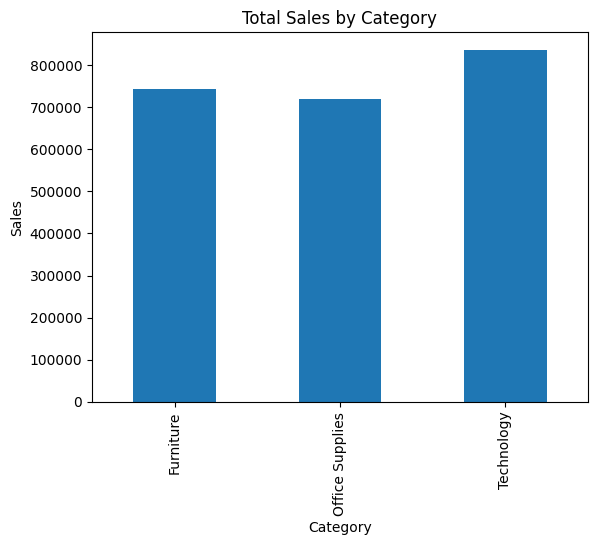

In [11]:
category_summary["Sales"].plot(kind="bar")
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.show()

In [12]:
subcat_profit = ( df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False))
subcat_profit.head(10)

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


In [13]:
# To show lowest profit categories
subcat_profit.tail(10)

,Profit
Sub-Category,
Appliances,18138.0054
Furnishings,13059.1436
Envelopes,6964.1767
Art,6527.7870
Labels,5546.2540
Machines,3384.7569
Fasteners,949.5182
Supplies,-1189.0995
Bookcases,-3472.5560


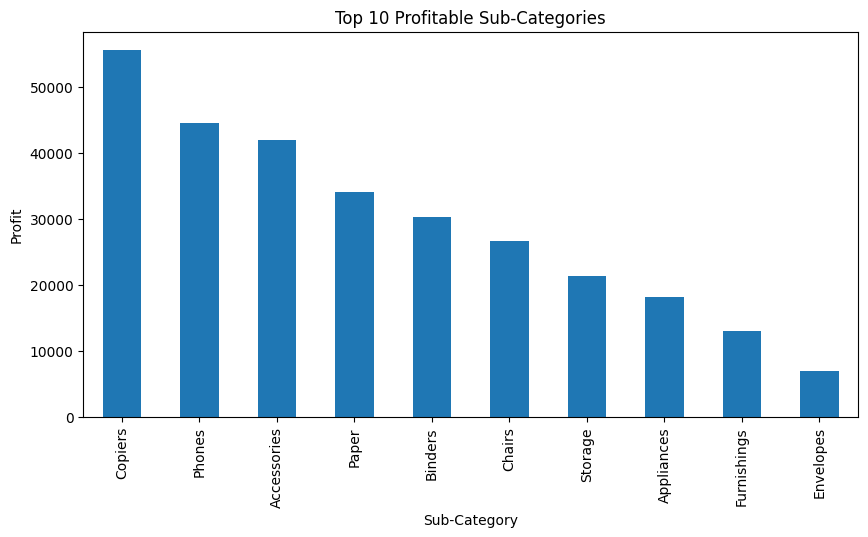

In [14]:
top10 = subcat_profit.head(10)

plt.figure(figsize=(10,5))
top10.plot(kind="bar")
plt.title("Top 10 Profitable Sub-Categories")
plt.ylabel("Profit")
plt.show()

In [15]:
tables_data = df[df["Sub-Category"] == "Tables"]
tables_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
10,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
24,25,CA-2015-106320,9/25/2015,9/30/2015,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,...,84057,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3,0.00,240.2649
117,118,CA-2015-110457,3/2/2015,3/6/2015,Standard Class,DK-13090,Dave Kipp,Consumer,United States,Seattle,...,98103,West,FUR-TA-10001768,Furniture,Tables,Hon Racetrack Conference Tables,787.5300,3,0.00,165.3813
125,126,US-2014-134614,9/20/2014,9/25/2014,Standard Class,PF-19165,Philip Fox,Consumer,United States,Bloomington,...,61701,Central,FUR-TA-10004534,Furniture,Tables,Bevis 44 x 96 Conference Tables,617.7000,6,0.50,-407.6820


In [16]:
tables_data[["Sales", "Discount", "Profit"]].describe()

,Sales,Discount,Profit
count,319.000000,319.000000,319.000000
mean,648.794771,0.261285,-55.565771
std,615.774655,0.169622,230.565006
min,24.368000,0.000000,-1862.312400
25%,244.006000,0.200000,-122.829300
50%,447.840000,0.300000,-31.372200
75%,872.170000,0.400000,33.851700
max,4297.644000,0.500000,629.010000


In [17]:
#  To get sub-category with highest average discount

discount_analysis = (df.groupby("Sub-Category")["Discount"].mean().sort_values(ascending=False))
discount_analysis.head(10)

,Discount
Sub-Category,
Binders,0.372292
Machines,0.306087
Tables,0.261285
Bookcases,0.211140
Chairs,0.170178
Appliances,0.166524
Copiers,0.161765
Phones,0.154556
Furnishings,0.138349


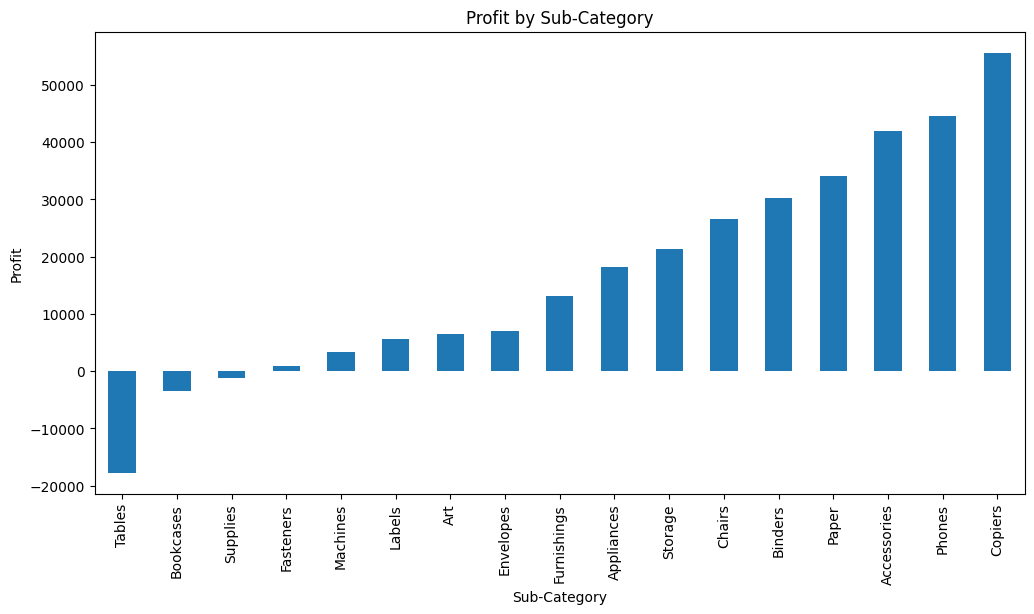

In [18]:
plt.figure(figsize=(12,6))

subcat_profit.sort_values().plot(kind="bar")

plt.title("Profit by Sub-Category")
plt.ylabel("Profit")

plt.show()


In [19]:
df[["Sales", "Quantity", "Discount", "Profit"]].corr()
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


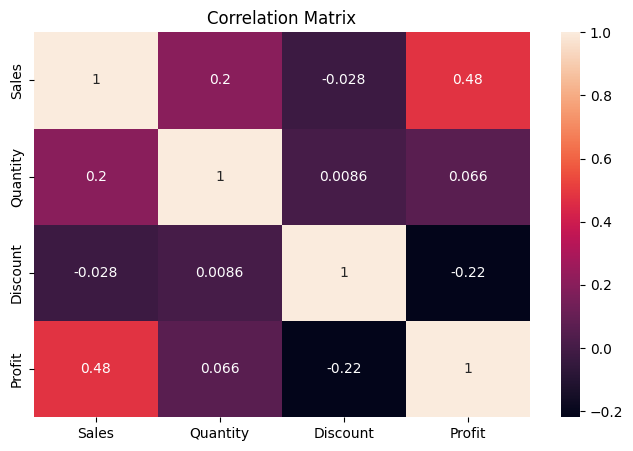

In [20]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[["Sales", "Quantity", "Discount", "Profit"]].corr(),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

In [21]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [22]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [23]:
df["Year"] = df["Order Date"].dt.year

In [24]:
df["Year"]

,Year
0,2016
1,2016
2,2016
3,2015
4,2015
...,...
9989,2014
9990,2017
9991,2017
9992,2017


In [25]:
df[["Sales", "Quantity", "Discount", "Profit"]].corr()

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


In [26]:
year_sales = df.groupby("Year")["Sales"].sum().round(2)
year_sales

,Sales
Year,
2014,484247.50
2015,470532.51
2016,609205.60
2017,733215.26


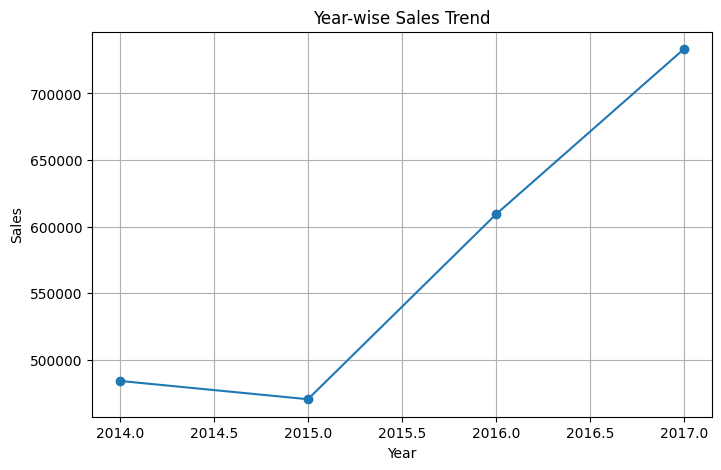

In [27]:
plt.figure(figsize=(8,5))

year_sales.plot(marker="o")

plt.title("Year-wise Sales Trend")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

In [28]:
df["Month"] = df["Order Date"].dt.month
df["Month"]

,Month
0,11
1,11
2,6
3,10
4,10
...,...
9989,1
9990,2
9991,2
9992,2


In [29]:
month_sales = df.groupby("Month")["Sales"].sum().round(2)
month_sales

,Sales
Month,
1,94924.84
2,59751.25
3,205005.49
4,137762.13
5,155028.81
6,152718.68
7,147238.10
8,159044.06
9,307649.95


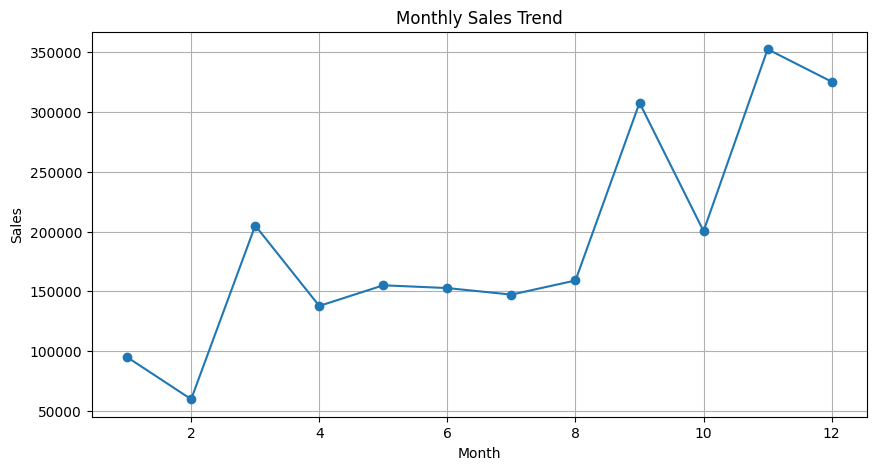

In [30]:
plt.figure(figsize=(10,5))

month_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

# Key Business Insights

### Model to predict Profit based on Sales, Quantity and Discount

1. Technology generated the highest overall profit.

2. Sales was identified as the strongest contributor to profitability.

3. High discount rates were associated with lower profits.

4. Tables and Bookcases generated losses despite significant sales volume.

5. Sales peaked during November and December, indicating seasonal demand.

# Exploratory Machine Learning Analysis

In [31]:
ml_df = df[["Sales", "Quantity", "Discount", "Profit"]]

ml_df.head()


,Sales,Quantity,Discount,Profit
0,261.9600,2,0.00,41.9136
1,731.9400,3,0.00,219.5820
2,14.6200,2,0.00,6.8714
3,957.5775,5,0.45,-383.0310
4,22.3680,2,0.20,2.5164


In [32]:
X = ml_df[["Sales", "Quantity", "Discount"]]

y = ml_df["Profit"]

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [36]:
y_pred = model.predict(X_test)

In [37]:
comparison = pd.DataFrame({
    "Actual Profit": y_test,
    "Predicted Profit": y_pred
})

comparison.head(10)

,Actual Profit,Predicted Profit
3125,21.1428,107.871130
1441,11.4600,-15.809824
4510,17.1580,26.124780
39,-15.1470,2.276068
4509,-6.4233,12.588835
1599,8.6744,-12.634768
7363,-73.7061,14.617286
9951,8.6900,20.958819
500,-15.0800,-123.883359
4847,17.9080,-65.351777


In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [39]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", round(mae, 2))

MAE: 69.77


In [40]:
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", round(rmse, 2))

RMSE: 289.12


In [41]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", round(r2, 4))

R2 Score: -0.7241


In [42]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Sales,0.259335
1,Quantity,-6.512035
2,Discount,-208.858709


In [43]:
ml_df = df[ ["Sales","Quantity","Discount","Category","Segment","Region","Profit"] ]
ml_df.head()

,Sales,Quantity,Discount,Category,Segment,Region,Profit
0,261.9600,2,0.00,Furniture,Consumer,South,41.9136
1,731.9400,3,0.00,Furniture,Consumer,South,219.5820
2,14.6200,2,0.00,Office Supplies,Corporate,West,6.8714
3,957.5775,5,0.45,Furniture,Consumer,South,-383.0310
4,22.3680,2,0.20,Office Supplies,Consumer,South,2.5164


In [44]:
ml_df_encoded = pd.get_dummies(
    ml_df,
    columns=["Category", "Segment", "Region"],
    drop_first=True
)

In [45]:
ml_df_encoded.head()

,Sales,Quantity,Discount,Profit,Category_Office Supplies,Category_Technology,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West
0,261.9600,2,0.00,41.9136,False,False,False,False,False,True,False
1,731.9400,3,0.00,219.5820,False,False,False,False,False,True,False
2,14.6200,2,0.00,6.8714,True,False,True,False,False,False,True
3,957.5775,5,0.45,-383.0310,False,False,False,False,False,True,False
4,22.3680,2,0.20,2.5164,True,False,False,False,False,True,False


In [46]:
X = ml_df_encoded.drop("Profit", axis=1)
y = ml_df_encoded["Profit"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
from sklearn.ensemble import RandomForestRegressor

In [49]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [50]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [51]:
rf_pred = rf_model.predict(X_test)

In [52]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R2:", round(rf_r2, 4))

MAE: 31.65
RMSE: 231.44
R2: -0.1048


In [53]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
0,Sales,0.764740
2,Discount,0.167283
1,Quantity,0.022731
4,Category_Technology,0.009702
5,Segment_Corporate,0.009501
3,Category_Office Supplies,0.007495
8,Region_South,0.005595
9,Region_West,0.004952
7,Region_East,0.004644
6,Segment_Home Office,0.003358


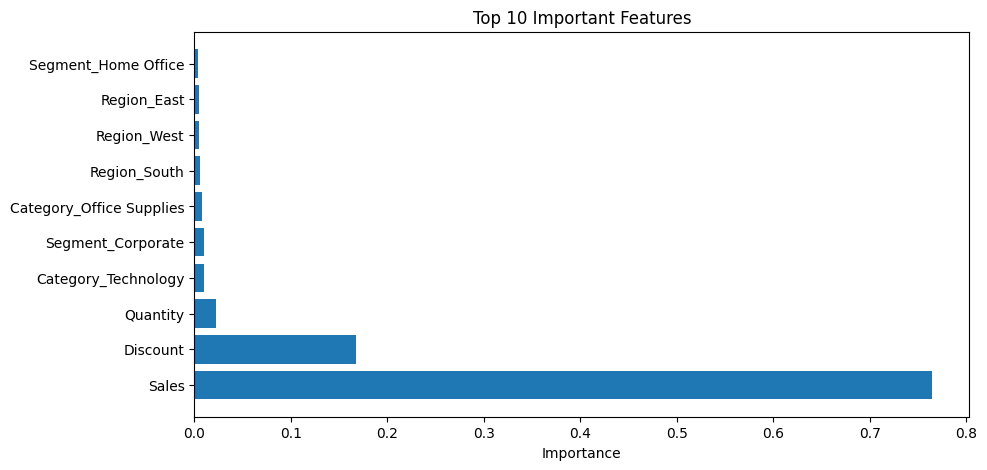

In [54]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")

plt.show()

In [55]:
importance_df.head(10)

,Feature,Importance
0,Sales,0.764740
2,Discount,0.167283
1,Quantity,0.022731
4,Category_Technology,0.009702
5,Segment_Corporate,0.009501
3,Category_Office Supplies,0.007495
8,Region_South,0.005595
9,Region_West,0.004952
7,Region_East,0.004644
6,Segment_Home Office,0.003358


# Model Evaluation Summary

Random Forest outperformed Linear Regression in terms of MAE and RMSE. However, predictive performance remained limited due to the absence of important business variables such as product cost and operational expenses. The experiment highlights the importance of feature selection and data quality in predictive analytics.

# Conclusion
This analysis identified key factors affecting profitability in retail operations. Sales and discount strategies were found to have the greatest impact on profit. While predictive modeling achieved limited performance due to missing cost-related information, the project successfully demonstrated the complete data analytics workflow, including data cleaning, exploratory analysis, visualization, feature engineering, and machine learning experimentation.